---

This Notebook creation considered as base this sources

1. Sequence classification Notebook
https://colab.research.google.com/github/huggingface/notebooks/blob/main/transformers_doc/en/pytorch/sequence_classification.ipynb

2. Text Classification Notebook https://colab.research.google.com/github/huggingface/notebooks/blob/main/examples/text_classification.ipynb

3. Tasks: Text Classification guide https://huggingface.co/docs/transformers/en/tasks/sequence_classification

4. Transformers: distilbert model documentation and guide https://huggingface.co/docs/transformers/model_doc/distilbert

---

Citation of the SEAHORSE Dataset:
E. Clark, S. Rijhwani, S. Gehrmann, J. Maynez, R. Aharoni, V. Nikolaev,
T. Sellam, A. Siddhant, D. Das, and A. P. Parikh, “Seahorse: A
multilingual, multifaceted dataset for summarization evaluation,” 2023, GitHub
Website: https://github.com/google-research-datasets/seahorse , HuggingFace
page: https://huggingface.co/datasets/SEACrowd/seahorse. [Online]. Available:
https://arxiv.org/abs/2305.13194

---

# **Seahorse Dataset with DestilBert**

#### **1.** Import libraries

In [1]:
import wget
import zipfile

from datasets import load_dataset,Dataset
import pandas as pd

import os
from pathlib import Path

In [2]:
# Reproducibility configuration

import os

# Deterministic cuBLAS workspace
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"


import torch
import numpy as np
import random
from transformers import set_seed


seed = 42
set_seed(seed)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

#### **2. Getting the SEAHORSE dataset**

First we download, extract and load the _Seahorse_ Dataset.

We get the following:

* 3 `.csv` files for `Train/Validation/Test` splits.
* A directory/folder called `duplicates`.

The Authors of Seahorse explain that the "duplicates" folder corresponds to texts that received multiple annotations.

They indicate to NOT USE this data for training metrics due to  overlaps.

In [3]:
# In case we already have the dataset file, we skip download+extract.
file_path = Path("seahorse_data.zip")
if not file_path.is_file():
    url = "https://storage.googleapis.com/seahorse-public/seahorse_data.zip"
    filename = wget.download(url)
    with zipfile.ZipFile("seahorse_data.zip", 'r') as zip_ref:
        zip_ref.extractall()

In [4]:
seahorse_dataset = load_dataset(
    "csv",
    data_files = {
        "train": "seahorse_data/train.tsv",
        "validation": "seahorse_data/validation.tsv",
        "test": "seahorse_data/test.tsv"
    },
    delimiter="\t"
)

In [5]:
seahorse_dataset

DatasetDict({
    train: Dataset({
        features: ['gem_id', 'worker_lang', 'summary', 'model', 'question1', 'question2', 'question3', 'question4', 'question5', 'question6'],
        num_rows: 60980
    })
    validation: Dataset({
        features: ['gem_id', 'worker_lang', 'summary', 'model', 'question1', 'question2', 'question3', 'question4', 'question5', 'question6'],
        num_rows: 8968
    })
    test: Dataset({
        features: ['gem_id', 'worker_lang', 'summary', 'model', 'question1', 'question2', 'question3', 'question4', 'question5', 'question6'],
        num_rows: 18330
    })
})

#### **2.** Initial modifications

We apply some initial convenient changes to the format.

* Change Yes/No String encoding of target values to Integers 0/1,
* Drop-remove non-used columns.
* Rename columns for readability.
* Remove NaN-Null-None valued text field rows.

In [6]:
# 1. Cast dataset object to a pandas dataframe to use the methods and functions of Pandas.
seahorse_dataset_train_df      = seahorse_dataset["train"].to_pandas()
seahorse_dataset_validation_df = seahorse_dataset["validation"].to_pandas()
seahorse_dataset_test_df       = seahorse_dataset["test"].to_pandas()

In [7]:
for df in [seahorse_dataset_train_df, seahorse_dataset_validation_df]:
  df.replace({'No': 0, 'Yes': 1}, inplace=True) # Substitute word Labels for Integers
  df.drop(columns=['gem_id', "model", "question4", "question5", "question6"], inplace=True) #Simplify removing unused columns
  df.rename(columns={"summary": "text",
                     "question1": "comprehensible",
                     "question2": "repetition_free",
                     "question3": "grammatical",
                     "worker_lang": "language"}, inplace=True)
  df.drop_duplicates(subset=["text"], inplace=True) # remove duplicated texts
  df.dropna(subset=["text"], inplace=True)          # remove rows with missing text

In [8]:
#df.duplicated(subset=["text"]).sum()
#df.isna().any(axis=1).sum()
#df[["text"]].isna().any(axis=1).sum()

np.int64(29)

np.int64(891)

np.int64(0)

In [8]:
#print(type(df))    # useful to check Dataframe or View. Pointer works ok.
#print(df._is_view)

In addition to Nan-Null-None values, spaces may be a special case. We check how many rows match this pattern of text.

We find that there is only one empty or whitespace text per dataset, and both are labeled as non comprehensible which is intuitive.

Therefore we keep these rows.

In [9]:
df = seahorse_dataset_validation_df

# Regex pattern for empty or whitespace-only strings
pattern = r"^\s*$"
print(seahorse_dataset_train_df[seahorse_dataset_train_df["text"].str.match(pattern, na=False)])
print(seahorse_dataset_validation_df[seahorse_dataset_validation_df["text"].str.match(pattern, na=False)])

      language text comprehensible repetition_free grammatical
38677       tr                   0            None        None
     language text comprehensible repetition_free grammatical
6674    en-US                   0            None        None


#### **3.** Keep `None` values in grammar and repetition columns

We can find None values in grammar and repetition columns.

The seahorse paper explains that when a row is not comprehensible the annotators policy is to not evaluate these other dimensions.

This means that in all rows useful for grammar and repetition dimensions, comprehensible is always Class 1/Positive.


Also note that unsure ratings are very few.

In [10]:
print(seahorse_dataset_train_df["comprehensible"].value_counts(dropna=False),
      seahorse_dataset_train_df["repetition_free"].value_counts(dropna=False),
      seahorse_dataset_train_df["grammatical"].value_counts(dropna=False), sep="\n\n")

comprehensible
1         54615
0          5904
Unsure      115
Name: count, dtype: int64

repetition_free
1         48568
0          6148
None       5904
Unsure       14
Name: count, dtype: int64

grammatical
1         49067
None       5904
0          5612
Unsure       51
Name: count, dtype: int64


In [11]:
print(seahorse_dataset_validation_df["comprehensible"].value_counts(dropna=False),
      seahorse_dataset_validation_df["repetition_free"].value_counts(dropna=False),
      seahorse_dataset_validation_df["grammatical"].value_counts(dropna=False), sep="\n\n")

comprehensible
1         8038
0          870
Unsure      31
Name: count, dtype: int64

repetition_free
1         7129
0          937
None       870
Unsure       3
Name: count, dtype: int64

grammatical
1         7228
None       870
0          825
Unsure      16
Name: count, dtype: int64


**Remove rows with `Unsure` rating**

For binary classification and predict Class-Labels 0/1.

In [12]:
seahorse_dataset_train_df = seahorse_dataset_train_df[
    ~( (seahorse_dataset_train_df["comprehensible"]         == "Unsure")
            | (seahorse_dataset_train_df["repetition_free"] == "Unsure")
            | (seahorse_dataset_train_df["grammatical"]     == "Unsure")
    )].copy()
        # in pandas logical expressions must use | for OR and use ().

seahorse_dataset_validation_df = seahorse_dataset_validation_df[
    ~( (seahorse_dataset_validation_df["comprehensible"]         == "Unsure")
            | (seahorse_dataset_validation_df["repetition_free"] == "Unsure")
            | (seahorse_dataset_validation_df["grammatical"]         == "Unsure")
    )].copy()

In [13]:
print(seahorse_dataset_train_df["comprehensible"].value_counts(dropna=False),
      seahorse_dataset_train_df["repetition_free"].value_counts(dropna=False),
      seahorse_dataset_train_df["grammatical"].value_counts(dropna=False), sep="\n\n")

# We still see the None values from uncomprehensible rows. It is ok.

comprehensible
1    54566
0     5904
Name: count, dtype: int64

repetition_free
1       48442
0        6124
None     5904
Name: count, dtype: int64

grammatical
1       49009
None     5904
0        5557
Name: count, dtype: int64


In [14]:
print(seahorse_dataset_validation_df["comprehensible"].value_counts(dropna=False),
      seahorse_dataset_validation_df["repetition_free"].value_counts(dropna=False),
      seahorse_dataset_validation_df["grammatical"].value_counts(dropna=False), sep="\n\n")

comprehensible
1    8025
0     870
Name: count, dtype: int64

repetition_free
1       7100
0        925
None     870
Name: count, dtype: int64

grammatical
1       7218
None     870
0        807
Name: count, dtype: int64


The dataset has intervals of same language texts. We shuffle the dataset thinking of future algorithms that may get affected by this sortings.

In [15]:
list(seahorse_dataset_train_df["language"])

['en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'en-US',
 'de',
 'de',
 'de',
 'de',
 'de',
 'de',
 'de',
 'de',
 'de',
 'de',
 'de',
 'de',
 'de',
 'de',
 'de',
 'de',
 'de',
 'de',
 'de',
 'de',
 'de',
 'de',
 'de',
 'de',
 'de',
 'de',
 'de',
 

In [16]:
from sklearn.utils import shuffle

seahorse_dataset_train_shuffled_df      = shuffle(seahorse_dataset_train_df     , random_state=42)
seahorse_dataset_validation_shuffled_df = shuffle(seahorse_dataset_validation_df, random_state=42)

In [17]:
list(seahorse_dataset_train_shuffled_df["language"])

['de',
 'en-US',
 'en-US',
 'en-US',
 'ru',
 'en-US',
 'ru',
 'en-US',
 'en-US',
 'ru',
 'en-US',
 'es-ES',
 'en-US',
 'vi',
 'tr',
 'ru',
 'de',
 'en-US',
 'es-ES',
 'tr',
 'vi',
 'es-ES',
 'en-US',
 'tr',
 'de',
 'de',
 'ru',
 'ru',
 'es-ES',
 'vi',
 'ru',
 'vi',
 'vi',
 'ru',
 'en-US',
 'ru',
 'vi',
 'de',
 'de',
 'en-US',
 'de',
 'en-US',
 'es-ES',
 'es-ES',
 'es-ES',
 'tr',
 'en-US',
 'ru',
 'es-ES',
 'vi',
 'es-ES',
 'ru',
 'es-ES',
 'es-ES',
 'de',
 'es-ES',
 'es-ES',
 'de',
 'es-ES',
 'en-US',
 'tr',
 'en-US',
 'es-ES',
 'de',
 'tr',
 'es-ES',
 'es-ES',
 'es-ES',
 'en-US',
 'en-US',
 'es-ES',
 'ru',
 'tr',
 'vi',
 'tr',
 'tr',
 'es-ES',
 'ru',
 'de',
 'de',
 'de',
 'tr',
 'ru',
 'de',
 'ru',
 'tr',
 'vi',
 'vi',
 'es-ES',
 'tr',
 'es-ES',
 'en-US',
 'de',
 'de',
 'en-US',
 'de',
 'de',
 'ru',
 'ru',
 'es-ES',
 'en-US',
 'en-US',
 'en-US',
 'vi',
 'es-ES',
 'en-US',
 'ru',
 'de',
 'en-US',
 'ru',
 'es-ES',
 'ru',
 'en-US',
 'ru',
 'es-ES',
 'es-ES',
 'de',
 'es-ES',
 'es-ES',
 '

Below, we see the structure of the Dataframe useful for working on _Comprehensible_ dimension.

It has rows for both classes. Note again that a row that is not comprehensible has no annotations for

the other dimensions. These are indeed set to `None`.

In [18]:
seahorse_dataset_train_shuffled_df[10:15] #A representative slice of dataset.

,language,text,comprehensible,repetition_free,grammatical
4221,en-US,Shut off the power to the water heater. Remove...,1,1,1
18817,es-ES,Para tener la mejor vista del vasto puerto esp...,1,1,1
32534,en-US,The company has fallen in a sharp recall of fa...,1,1,1
12494,vi,Công an TP Hà Nội đã công an thăm nhà tướng Tr...,0,None,None
18001,tr,İtalya'da İtalyan yönetmeni Reha Erdem'in 'Koc...,1,1,0


#### **4.** Drop rows without annotation for Repetition and Grammatical dimensions

For _Repetition_ and _Grammar_ dimensions we keep only rows that are comprehensible.

We also make sure that all final ratings are either zero or one by dropping rows with **None** values.

In [19]:
#Dataframes to be used for repetition and grammar.

seahorse_dataset_train_df_subset_comprehensible_is_yes = seahorse_dataset_train_shuffled_df[seahorse_dataset_train_shuffled_df
                                                                                            ['comprehensible'] == 1].copy()
seahorse_dataset_train_df_subset_comprehensible_is_yes.dropna(inplace=True)


seahorse_dataset_validation_df_subset_comprehensible_is_yes = seahorse_dataset_validation_shuffled_df[seahorse_dataset_validation_shuffled_df
                                                                                             ['comprehensible'] == 1].copy()
seahorse_dataset_validation_df_subset_comprehensible_is_yes.dropna(inplace=True)

This is the structure of the DataFrame to be used for Repetition and Grammar.

Notice how in the comprehensible column all rows have value one.

In [20]:
seahorse_dataset_train_df_subset_comprehensible_is_yes[126:132] # representative structure slice

,language,text,comprehensible,repetition_free,grammatical
7900,de,Geräusche übertönen. Nach jedem Abgang spülen....,1,1,1
45845,en-US,"A burst water main in Castlemilk affected 5,50...",1,1,1
39971,en-US,Gather your supplies. Let it sit on your nails...,1,1,1
25059,vi,Một báo cáo năm 2016 nói các vụ hành hạ ở thàn...,1,0,0
6884,en-US,Use bug sprays and topical creams. Spray insec...,1,0,1
6301,de,Gehe mit deinem Arzt.,1,1,0


#### **5.** Balancing of Classes (Not used in models)

The classes distribution are clearly unbalanced. Most instances satisfy the assessed quality dimensions (with coded value 1).

One option to manage this is to downsample to obtain a 50/50 Positive-1 / Negative-0 ratio for each dimension in order to create datasets that we can use for  training without inserting a bias towards the original majority class. We show how this is done and later we save files of balanced train datasets.

In our models we used other approach: using weighted Loss.

In [21]:
from sklearn.utils import resample

df_sources = [seahorse_dataset_train_shuffled_df, seahorse_dataset_train_df_subset_comprehensible_is_yes, seahorse_dataset_train_df_subset_comprehensible_is_yes]


df_vars = [None, None, None] # initialize list to save results.
columns_names = ["comprehensible", "grammatical", "repetition_free"]


for i in range(0, 3):
    df = df_sources[i]                            # get dataframe relevant for current dimension
    df_majority = df[df[columns_names[i]] == 1]  # filter and get two dataframes split by current dimension class values
    df_minority = df[df[columns_names[i]] == 0]

    # Downsample majority class
    df_majority_downsampled = resample(df_majority,
                                       replace=False,                 # sample without replacement
                                       n_samples=len(df_minority),    # match minority class
                                       random_state=42)

    # Combine minority and downsampled majority
    df_balanced = pd.concat([df_majority_downsampled, df_minority])

    # Shuffle the balanced dataset so it is not organized in positive-negative intevals as we got from concatenation.
    # (now it is like 111111000000, is better 10010110010).
    df_balanced = shuffle(df_balanced, random_state=42)
    df_vars[i] = df_balanced.copy()

df_comprehensible_balanced = df_vars[0]  # save results into variables with intuitive names
df_grammar_balanced        = df_vars[1]
df_repetition_balanced     = df_vars[2]

#### **6.** Sizes and slices of dataframes

This Notebook is deterministic so running it will show the same results and generate the same files.

In [22]:
# Dataset sizes and class counts
print(seahorse_dataset_train_shuffled_df["comprehensible"].value_counts(dropna=False),
      seahorse_dataset_train_shuffled_df["repetition_free"].value_counts(dropna=False),
      seahorse_dataset_train_shuffled_df["grammatical"].value_counts(dropna=False), sep="\n\n")

comprehensible
1    54566
0     5904
Name: count, dtype: int64

repetition_free
1       48442
0        6124
None     5904
Name: count, dtype: int64

grammatical
1       49009
None     5904
0        5557
Name: count, dtype: int64


In [23]:
# Dataset sizes and class counts
print(seahorse_dataset_validation_shuffled_df["comprehensible"].value_counts(dropna=False),
      seahorse_dataset_validation_shuffled_df["repetition_free"].value_counts(dropna=False),
      seahorse_dataset_validation_shuffled_df["grammatical"].value_counts(dropna=False), sep="\n\n")

comprehensible
1    8025
0     870
Name: count, dtype: int64

repetition_free
1       7100
0        925
None     870
Name: count, dtype: int64

grammatical
1       7218
None     870
0        807
Name: count, dtype: int64


In [24]:
# Dataset sizes and class counts
print(seahorse_dataset_train_df_subset_comprehensible_is_yes["comprehensible"].value_counts(dropna=False),
      seahorse_dataset_train_df_subset_comprehensible_is_yes["repetition_free"].value_counts(dropna=False),
      seahorse_dataset_train_df_subset_comprehensible_is_yes["grammatical"].value_counts(dropna=False), sep="\n\n")

comprehensible
1    54566
Name: count, dtype: int64

repetition_free
1    48442
0     6124
Name: count, dtype: int64

grammatical
1    49009
0     5557
Name: count, dtype: int64


In [25]:
# Dataset sizes and class counts
print(seahorse_dataset_validation_df_subset_comprehensible_is_yes["comprehensible"].value_counts(dropna=False),
      seahorse_dataset_validation_df_subset_comprehensible_is_yes["repetition_free"].value_counts(dropna=False),
      seahorse_dataset_validation_df_subset_comprehensible_is_yes["grammatical"].value_counts(dropna=False), sep="\n\n")

comprehensible
1    8025
Name: count, dtype: int64

repetition_free
1    7100
0     925
Name: count, dtype: int64

grammatical
1    7218
0     807
Name: count, dtype: int64


In [26]:
df_comprehensible_balanced["comprehensible"].value_counts(dropna=False)

comprehensible
0    5904
1    5904
Name: count, dtype: int64

In [27]:
df_grammar_balanced["grammatical"].value_counts(dropna=False)

grammatical
1    5557
0    5557
Name: count, dtype: int64

In [28]:
df_repetition_balanced["repetition_free"].value_counts(dropna=False)

repetition_free
1    6124
0    6124
Name: count, dtype: int64

In [29]:
df_comprehensible_balanced[0:3]

,language,text,comprehensible,repetition_free,grammatical
29949,vi,"Trung Quốc đã mời thầu tại Hoàng Sa, nơi Trung...",0,None,None
33742,es-ES,Abre un alimento inicial para terneros.,0,None,None
9940,tr,"ABD Savunma Bakanı Vladimir Putin, Suriye'de S...",1,0,0


In [30]:
df_grammar_balanced[0:3]

,language,text,comprehensible,repetition_free,grammatical
6712,en-US,Watch for falling frequently. Notice difficult...,1,1,1
33534,es-ES,El problema de la evasión tecnológica acabará ...,1,1,1
5833,de,Wähle deine Farben.,1,1,1


In [31]:
df_repetition_balanced[0:3]

,language,text,comprehensible,repetition_free,grammatical
17008,en-US,Liverpool's former Littlewoods Pools building ...,1,1,1
14830,tr,"WhatsApp, siber saldırıların ardından, ülkede ...",1,0,1
26731,ru,Попробуйте прокладки. Попробуйте прокладки.,1,0,1


In [32]:
seahorse_dataset_train_shuffled_df[0:3]

,language,text,comprehensible,repetition_free,grammatical
48128,de,Wasche die Jeans mit Essig und heißem Wasser. ...,1,1,1
38192,en-US,Coronation Street is to broadcast a live episo...,1,1,1
867,en-US,British director Steve McQueen has dedicated h...,1,1,1


In [33]:
seahorse_dataset_train_df_subset_comprehensible_is_yes[0:3]

,language,text,comprehensible,repetition_free,grammatical
48128,de,Wasche die Jeans mit Essig und heißem Wasser. ...,1,1,1
38192,en-US,Coronation Street is to broadcast a live episo...,1,1,1
867,en-US,British director Steve McQueen has dedicated h...,1,1,1


In [34]:
seahorse_dataset_validation_shuffled_df[0:3]

,language,text,comprehensible,repetition_free,grammatical
6428,en-US,Buy merchandise for your store. Acquire locall...,1,1,1
5386,ru,В ближайшее время депутат Госдумы Ганзя задекл...,0,None,None
4825,es-ES,"El trono del Crisantemo, el trono de Camboya, ...",1,1,0


In [35]:
seahorse_dataset_validation_df_subset_comprehensible_is_yes[0:3]

,language,text,comprehensible,repetition_free,grammatical
6428,en-US,Buy merchandise for your store. Acquire locall...,1,1,1
4825,es-ES,"El trono del Crisantemo, el trono de Camboya, ...",1,1,0
7922,en-US,Understand why making a budget is important. C...,1,1,1


##### **7.** Export to files

Save in `.csv` format copies of the balanced prepared train datasets. Useful for quick and easy use.

In [36]:
folder = "balanced_seahorse"
os.makedirs(folder, exist_ok=True)

df_comprehensible_balanced.to_csv(f"{folder}/df_train_comprehensible_balanced.csv", index=False)
df_repetition_balanced.to_csv(f"{folder}/df_train_repetition_balanced.csv", index=False)
df_grammar_balanced.to_csv(f"{folder}/df_train_grammar_balanced.csv", index=False)

Save in `.csv` format copies of the unbalanced train and validation datasets. Useful for quick and easy use.

In [37]:
folder = "unbalanced_seahorse"
os.makedirs(folder, exist_ok=True)

seahorse_dataset_train_shuffled_df.to_csv(f"{folder}/seahorse_dataset_train_df_unbalanced.csv", index=False)
seahorse_dataset_train_df_subset_comprehensible_is_yes.to_csv(f"{folder}/seahorse_dataset_train_df_subset_comprehensible_is_yes_unbalanced.csv", index=False)

seahorse_dataset_validation_shuffled_df.to_csv(f"{folder}/seahorse_dataset_validation_df_unbalanced.csv", index=False)
seahorse_dataset_validation_df_subset_comprehensible_is_yes.to_csv(f"{folder}/seahorse_dataset_validation_df_subset_comprehensible_is_yes_unbalanced.csv", index=False)

#### **8.** Verification whether max Tokens=512 is enough to manage Training and Validation sets

DestilBert can consume at most 512 tokens. We tokenize our datasets and verify which percentile corresponds to 512.

Even if some samples are longer than 512, this is not a problem, because the majority of data correctly fits in the available space.

Truncating is a strategy we can use for the non complying samples.

In [38]:
from transformers import AutoTokenizer
import matplotlib.pyplot as plt

text_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-multilingual-cased")

def preprocess_function(data):
    return text_tokenizer(data["text"]) # In each row the name of field is text



In [39]:
def check_tokens_overflow(dataframe_to_tokenize):

    Dataset_object = Dataset.from_pandas(dataframe_to_tokenize)
    tokenized = Dataset_object.map(preprocess_function, batched=True)

    #Compute percentile correponding to 512.
    l = np.array([len(ids) for ids in tokenized["input_ids"]])
    sorted_arr = np.sort(l)
    percentile = 100 * np.sum(sorted_arr <= 512) / len(l)
    print("Percentile("+ str(percentile) + ") = 512")

    # Plot histogram
    plt.hist(sorted_arr, bins='auto', color='skyblue')
    plt.axvline(x=512, color='green', linestyle='--', linewidth=2, label='512')
    plt.title("Token length")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

Map:   0%|          | 0/11808 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (541 > 512). Running this sequence through the model will result in indexing errors


Percentile(98.74661246612466) = 512


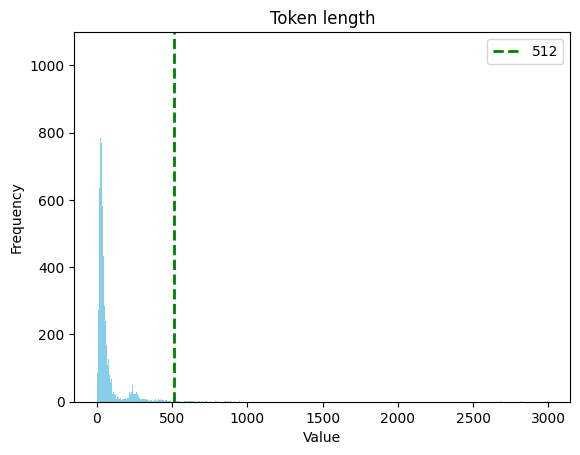

Map:   0%|          | 0/11114 [00:00<?, ? examples/s]

Percentile(99.87403275148462) = 512


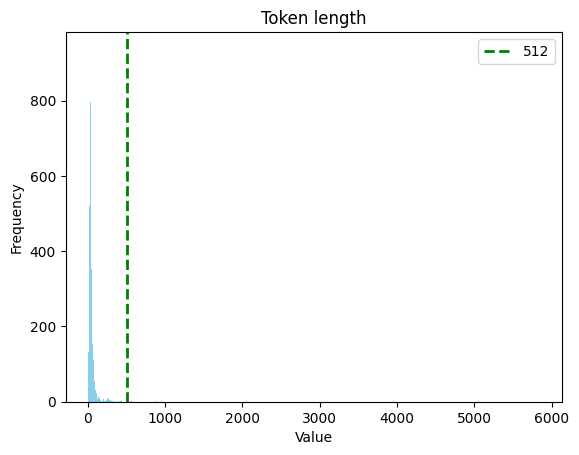

Map:   0%|          | 0/12248 [00:00<?, ? examples/s]

Percentile(99.55094709340301) = 512


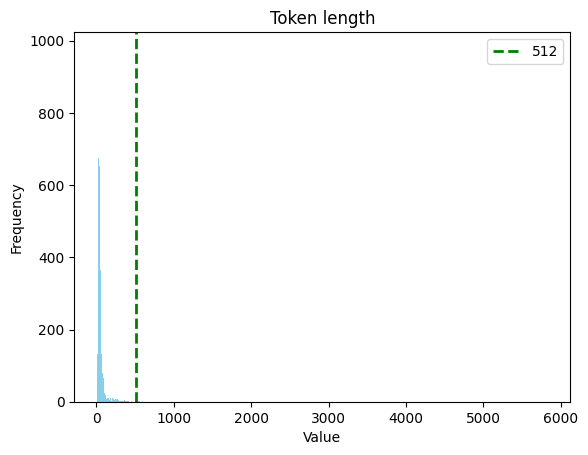

Map:   0%|          | 0/8895 [00:00<?, ? examples/s]

Percentile(99.64024732996066) = 512


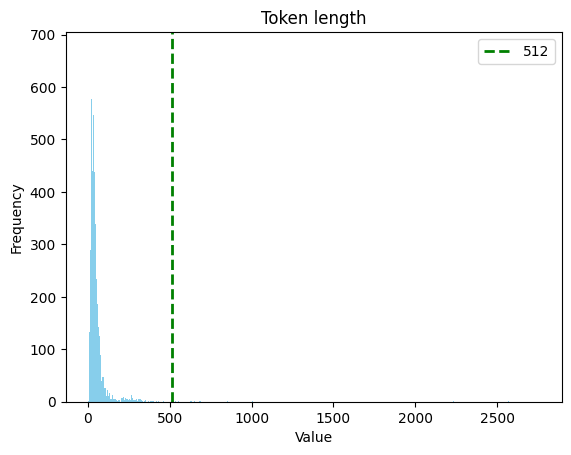

Map:   0%|          | 0/8025 [00:00<?, ? examples/s]

Percentile(99.8380062305296) = 512


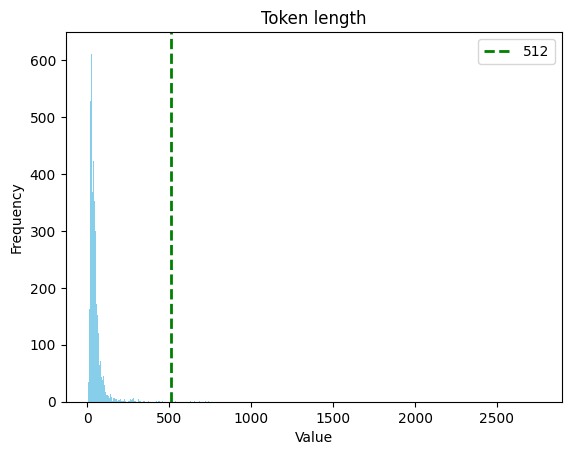

Map:   0%|          | 0/60470 [00:00<?, ? examples/s]

Percentile(99.66264263271043) = 512


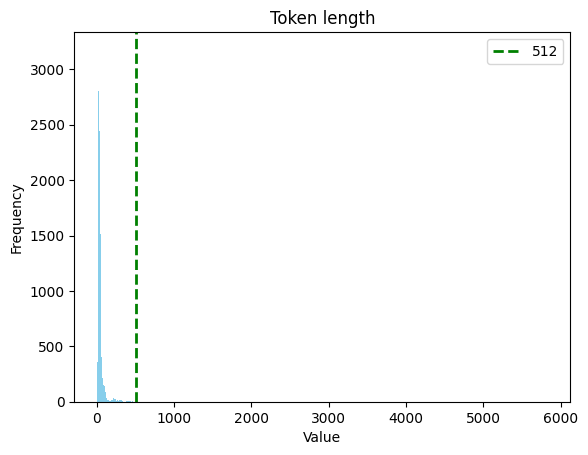

Map:   0%|          | 0/54566 [00:00<?, ? examples/s]

Percentile(99.88637613165707) = 512


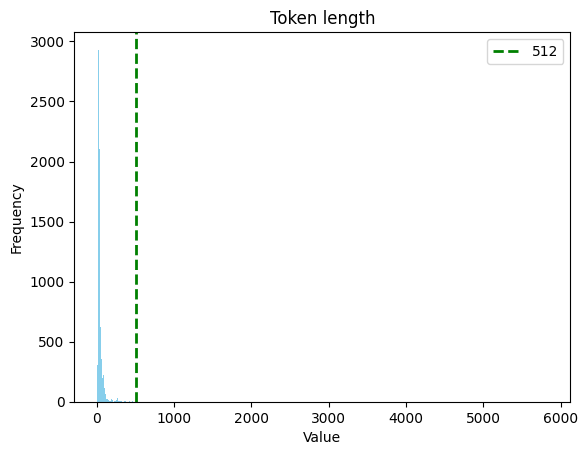

In [40]:
check_tokens_overflow(df_comprehensible_balanced)
check_tokens_overflow(df_grammar_balanced)
check_tokens_overflow(df_repetition_balanced)

check_tokens_overflow(seahorse_dataset_validation_shuffled_df)
check_tokens_overflow(seahorse_dataset_validation_df_subset_comprehensible_is_yes)

check_tokens_overflow(seahorse_dataset_train_shuffled_df)
check_tokens_overflow(seahorse_dataset_train_df_subset_comprehensible_is_yes)

In [41]:
# an example of a very long text longer than 512 tokens
Dataset_object = Dataset.from_pandas(df_comprehensible_balanced)
tokenized = Dataset_object.map(preprocess_function, batched=True)

longest_seq = max((ids for ids in tokenized["input_ids"]),key=len)
text_tokenizer.decode(longest_seq, skip_special_tokens=True)

Map:   0%|          | 0/11808 [00:00<?, ? examples/s]

'Haz clic en Nuevo. Haz clic en el icono de CD / DVD. Haz clic en Examinar. Selecciona el archivo ISO de Ubuntu. Haz clic en Abrir. Haz clic en Iniciar. Haz clic en Instalar Ubuntu. Haz clic en Siguiente. Haz clic en Siguiente. Haz clic en Siguiente. Haz clic en Siguiente. Haz clic en Siguiente. Haz clic en Siguiente. Haz clic en Siguiente. Haz clic en Siguiente. Haz clic en Siguiente. Haz clic en Siguiente. Haz clic en Siguiente. Haz clic en Siguiente. Haz clic en Siguiente. Haz clic en Siguiente. Haz clic en Siguiente. Haz clic en Siguiente. Haz clic en Siguiente. Haz clic en Siguiente. Haz clic en Siguiente. Haz clic en Siguiente. Haz clic en Siguiente. Haz clic en Siguiente. Haz clic en Siguiente. Haz clic en Siguiente. Haz clic en Siguiente. Haz clic en Siguiente. Haz clic en Siguiente. Haz clic en Siguiente. Haz clic en Siguiente. Haz clic en Siguiente. Haz clic en Siguiente. Haz clic en Siguiente. Haz clic en Siguiente. Haz clic en Siguiente. Haz clic en Siguiente. Haz clic en S

In [42]:
# When running complete Notebook, this will be cell [42].